In [40]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel , Field
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
import json
import re
load_dotenv()
base_url = "http://103.42.50.41:443/api1"
api_key = f'{("sk-Qp7f5gy8WRqJW2KRbhOrZVD280JJWdSo")}'
TAVILY_API_KEY ="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"

model = ChatOpenAI(model = 'Qwen/Qwen2.5-7B-Instruct-AWQ',
 openai_api_base=base_url, openai_api_key=api_key, streaming=False)


In [4]:
docs = (
    PyPDFLoader("/workspaces/Chatbot_Langgraph/7181-attention-is-all-you-need.pdf").load()
)
len(docs)
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(
    documents=chunks,  # your list of Document objects
    embedding=embeddings,
    persist_directory="./chroma_db")

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11420.46it/s]


In [5]:
lower_thr =0.3
upper_thr =0.7

In [35]:
class State(TypedDict):
    question: str
    docs: List[Document]
    good_docs : List[Document]
    verdict: str
    reason :str
    strips :List[str]
    kept_strips: List[str]
    refined_context: str
    answer: str
    web_docs : List[Document]

In [7]:
class doc_evaluation(BaseModel):
    score:float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | model.with_structured_output(doc_evaluation)

def eval_each_doc_node(state: State) -> State:

    q = state["question"]
    
    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > lower_thr:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > upper_thr for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {upper_thr}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < lower_thr for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {lower_thr}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {upper_thr}, but not all were < {lower_thr}. {why}",
    }



In [55]:
def decompose_to_sentences(text:str)->List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class KeepOrDrop(BaseModel):
    keep : bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

class KeepIndices(BaseModel):
    keep: List[int] = Field(
        default_factory=list,
        description="Indices of sentences that directly help answer the question.",
    )

batch_filter_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a strict relevance filter for RAG.\n"
        "You get a question and numbered sentences.\n"
        "Return the indices of sentences that directly help answer the question.\n"
        "Be conservative. Output JSON only.",
    ),
    ("human", "Question: {question}\n\nSentences:\n{numbered}"),
])
batch_filter_chain = batch_filter_prompt | model.with_structured_output(KeepIndices)

def filter_strips(question: str, strips: List[str]) -> List[str]:
    #strips = strips[:max_strips]                      # cap the prompt size
    numbered = "\n".join(f"{i}: {s}" for i, s in enumerate(strips))
    out = batch_filter_chain.invoke({"question": question, "numbered": numbered})
    if out is None:                                   # structured output failed: keep everything
        return strips
    return [strips[i] for i in out.keep if 0 <= i < len(strips)]


def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    if state["verdict"]=="CORRECT":
        docs_to_use = state["good_docs"]
    elif state["verdict"]=="INCORRECT":
       docs_to_use = state["web_docs"]
    else:
        docs_to_use = state["good_docs"] + state["web_docs"] 

    context = "\n\n".join(d.page_content for d in docs_to_use).strip() 

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept = filter_strips(q, strips)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [41]:
# -----------------------------
# Web search (Iteration 4)
# Assumption: web search does not fail (no fail node in this branch)
# -----------------------------
tavily = TavilySearchResults(max_results=5 , tavily_api_key = TAVILY_API_KEY)

def web_search_node(state: State) -> State:

    q = state["question"]  # no query rewrite
    results = tavily.invoke({"query": q })  # no knowledge selection
    web_docs_1 = []
    for r in results or []:

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs_1.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs_1}

In [9]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [10]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | model).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}


In [ ]:

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

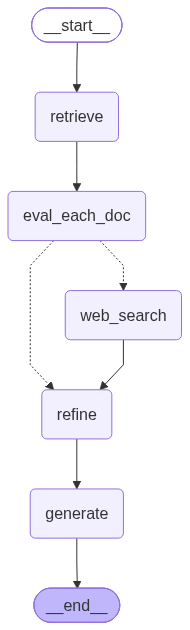

In [56]:

graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("eval_each_doc", eval_each_doc_node)
graph.add_node("refine", refine)
graph.add_node("web_search", web_search_node)
graph.add_node("generate", generate)


graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "eval_each_doc")

graph.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",          
        "web_search": "web_search",  
    },
)
graph.add_edge("web_search", "refine")    
graph.add_edge("refine", "generate") 
graph.add_edge("generate", END)

workflow = graph.compile()

workflow



In [57]:
res = workflow.invoke(
    {
        "question": "What does it mean by attention",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 Attention, in this context, refers to a mechanism in neural networks, particularly in transformer models, that allows the model to focus on specific parts of the input data when generating an output. It maps a query and a set of key-value pairs to an output, where the output is computed as a weighted sum of the values. The weights are determined by a compatibility function between the query and each key.


In [14]:
# 5) Run
res = workflow.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])



FAIL: All retrieved chunks scored < 0.3. No chunk was sufficient.


In [15]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

Figure 1: The Transformer - model architecture.
wise fully connected feed-forward network. We employ a residual connection [10] around each of
the two sub-layers, followed by layer normalization [ 1]. That is, the output of each sub-layer is
LayerNorm(x + Sublayer(x)), where Sublayer(x) is the function implemented by the sub-layer
itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding
layers, produce outputs of dimensiondmodel = 512.
Decoder: The decoder is also composed of a stack ofN = 6 identical layers. In addition to the two
sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head
attention over the output of the encoder stack. Similar to the encoder, we employ residual connections
around each of the sub-layers, followed by layer normalization. We also modify the self-attention
****************************************************************************************************
Figure 1: The 